In [ ]:
# MIT License
#
#@title Copyright (c) 2026 CCAI Community Authors { display-mode: "form" }
#
# Permission is hereby granted, free of charge, to any person obtaining a
# copy of this software and associated documentation files (the "Software"),
# to deal in the Software without restriction, including without limitation
# the rights to use, copy, modify, merge, publish, distribute, sublicense,
# and/or sell copies of the Software, and to permit persons to whom the
# Software is furnished to do so, subject to the following conditions:
#
# The above copyright notice and this permission notice shall be included in
# all copies or substantial portions of the Software.
#
# THE SOFTWARE IS PROVIDED "AS IS", WITHOUT WARRANTY OF ANY KIND, EXPRESS OR
# IMPLIED, INCLUDING BUT NOT LIMITED TO THE WARRANTIES OF MERCHANTABILITY,
# FITNESS FOR A PARTICULAR PURPOSE AND NONINFRINGEMENT. IN NO EVENT SHALL
# THE AUTHORS OR COPYRIGHT HOLDERS BE LIABLE FOR ANY CLAIM, DAMAGES OR OTHER
# LIABILITY, WHETHER IN AN ACTION OF CONTRACT, TORT OR OTHERWISE, ARISING
# FROM, OUT OF OR IN CONNECTION WITH THE SOFTWARE OR THE USE OR OTHER
# DEALINGS IN THE SOFTWARE.

# Predicting Mobility Demand From Urban Features

Authors:
*   Konstantin Klemmer, Microsoft Research & CCAI, konstantin@climatechange.ai
*   Shafat Rahman, CCAI, shafatrahman@climatechange.ai
*   Felix Wagner, TU Berlin & Mercator Research Institute on Global Commons and Climate Change, wagner@mcc-berlin.net
*   Florian Nachtigall, TU Berlin & Mercator Research Institute on Global Commons and Climate Change, nachtigall@tu-berlin.de
*   Gabriela Yaulli Herrera, Cornell Tech, cgy4@cornell.edu

## Learning Objectives

By the end of this tutorial, you will be able to:
* Explain how urban points-of-interest (POI) data can be used to model shared-bike demand, and why this matters for climate-friendly transport planning
* Build and compare three models (linear regression, gradient boosting, GNN) for a spatial prediction task, and evaluate them on unseen data
* Identify signs of over/underfitting and apply basic mitigation strategies
* Describe the key risks of applying a model like this one in a *different* city than the one it was trained on
* Discuss who would use this kind of model in practice, and what validation/governance should happen before its outputs inform real infrastructure decisions

**Prerequisites:** basic Python, pandas, and familiarity with linear regression. No prior GNN experience is required — the tutorial explains this as it goes.

# Table of Contents


*   [Overview](#overview)
*   [Climate Impact](#climate-impact)
*   [Background & Prerequisites](#background-and-prereqs)
*   [Software Requirements](#software-requirements)
*   [Data Description](#data-description)
*   [Methodology](#methodology)
    *   [Linear Regression](#lr)
    *   [Gradient Boosting Decision Trees](#gbdt)
    *   [Graph Neural Network (GNN)](#gnn)
*   [Results](#results)
*   [Discussion](#discussion)
    *   [Take-aways](#take-aways)
    *   [Limitations](#limitations)
    *   [Explainability](#explainability)
    *   [Deriving Policy Advice](#policy-advice)
    *   [Next Steps](#next-steps)
*   [References](#references)


# Exercises
1.   [Use XGBoost for prediction](#task-xgboost)
1.   [Optimize GNN hyperparameters](#"task-GNN-tune")
1.   [Optimize XGBOOST hyperparameters](#task-hyperparameters)
1.   [Policy advice: Predict optimal future bike stand location](#task-policy-advice)


<a name="overview"></a>
# Overview

In this tutorial, we investigate the relationship between urban characteristics, such as the location of different shops and services, and bike-sharing demand. From a dataset of shared bike trips in Shenzhen, we count the number of trips ending in each neighborhood in the city, and count the corresponding number of points of interest, such as medical services, transportation services, etc. Then, we apply linear regression and a graph neural network to model the relationship between POI densities and trip end densities.

Note: this tutorial is a single-city case study. The specific relationships we find between POIs and bike trips reflect Shenzhen's infrastructure, travel culture, and data collection process — later in the tutorial we discuss why these relationships may not transfer directly to other cities.

<a name="climate-impact"></a>
# Climate Impact

Studying bike-sharing data could help us determine the demand for shared bikes at different locations at different times of day and days of the week. This information can be used to make sure that enough bikes are available at bike stands during hours of peak demand, hence ensuring that commuters do not turn to less climate-friendly greenhouse gas-emitting modes of transportation because of a lack of shared bikes.

Modeling the relationship between bike usage and POIs can also inform where to set up new shared-bike stands. For example, if a lot of people prefer to bike to public transportation services, new shared-bike stands could be installed at bus and train stations that do not have shared-bike coverage.

Investigating areas with low shared-bike demand can reveal issues such as lack of bike lanes that are keeping more people from adopting greener transportation habits.

**Who would use this?** In practice, outputs like these would inform city transport planners and bike-share operators deciding where to invest in stands or bike lanes. The people most affected are residents of the areas gaining (or not gaining) new infrastructure — so an equity lens matters: a model trained mainly on existing, already-served areas can reinforce existing service gaps if applied uncritically.

<a name="background-and-prereqs"></a>
# Background & Prerequisites

To get the most out of this tutorial, you should have a basic understanding of data processing and cleaning. Familiarity with handling spatial data such are latitude and longitude coordinates will be helpful.

You should also be familiar with simple modeling techniques such as linear regression.




<a name="software-requirements"></a>
# Software Requirements

Below we will import the python libraries necessary for this tutorial. Some libraries have to be installed because they are not automatically available in Colab's Python environment.

In [1]:
import os
from pathlib import Path
import shutil
import warnings

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from shapely.geometry import Point
from sklearn.metrics import r2_score
from sklearn.linear_model import LinearRegression
from xgboost import XGBRegressor

%matplotlib inline

In [2]:
!pip install geopandas
!pip install openpyxl
!pip install h3pandas
!pip install shap
!pip install mapclassify

import openpyxl
import geopandas as gpd
import h3pandas
import shap

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.3/53.3 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 14.5 MB/s eta 0:00:00


In [3]:
import torch
os.environ['TORCH'] = torch.__version__
print(torch.__version__)

!pip install -q torch-scatter -f https://data.pyg.org/whl/torch-${TORCH}.html
!pip install -q torch-sparse -f https://data.pyg.org/whl/torch-${TORCH}.html
!pip install -q pyg-lib -f https://data.pyg.org/whl/torch-${TORCH}.html
!pip install -q torch-cluster -f https://data.pyg.org/whl/torch-${TORCH}.html
!pip install -q git+https://github.com/pyg-team/pytorch_geometric.git

2.11.0+cpu
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 682.1/682.1 kB 9.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 14.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 19.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 828.0/828.0 kB 9.4 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [4]:
# For now, we will disable some known warnings to improve the readability of the cell outputs.
warnings.resetwarnings()
warnings.simplefilter(action='ignore', category=DeprecationWarning)
warnings.simplefilter(action='ignore', category=FutureWarning)

<a name="data-description"></a>
# Data Description

Our data include:
* Shape files specifying locations of points of interest (POI) in folder ShenzhenPOI/ShapeFile. The filenames of the shape files include the POI category.
* The shenzhenPOI folder also contains an excel file called amap_poicode.xlsx which contains translations of POI category names from Chinese to English.
* Trip data from 2021 in the folder called 8.01-8.30.
* Shape files for Shenzhen, Shenzhen's population distribution, Shenzhen's bus and metro stops


**Datasheet brief:** This trip data was collected from a commercial bike-share operator in Shenzhen over four days in July 2021, so it reflects one season, one operator, and one city's cycling culture — not a general model of cycling behavior. POI data comes from a separate mapping provider and may lag real-world changes (new businesses, closures). We also work with a random subsample of the full trip data for speed, which can slightly distort rare/localized patterns. See [Gebru et al., 2018](https://arxiv.org/abs/1803.09010) for the full datasheet framework this is based on.

## Data Download
Our data is stored in a public Google Drive folder at https://drive.google.com/drive/u/3/folders/18bdGh6IIRhqKr3gPQhbuhkOgZykBrfqx. We can download the data using gdown.

The data download and extraction below should not take more than 5 minutes.

In [5]:
!gdown --folder --remaining-ok https://drive.google.com/drive/u/3/folders/1sLp2mWlBMX3mRnkTAzHcMBStCXLK2KDN -O /content/data/

Retrieving folder contents
Retrieving folder 1OinJcYU7BfJDrzE8AlTrHtdC9GDgjrw7 8.01-8.30
Processing file 1ROAzky8XOtq40FdrvO4_4iHMIfzUw40s shared_bike_data.zip
Retrieving folder 1Urx8M4i-XurgPGW43XghYQQ-jVVuLzn7 bus_metro
Retrieving folder 1uJBsF_UvqCZaLBpzMG_wEzGKG6atnVDR bus_station_shp
Processing file 1uYb-CvKS2FkqJVnYlTqiI7Oj74vShRqM bus_station_point.cpg
Processing file 1yGA8KxI7M7WCv69qHxr08qbzmoQkxMwP bus_station_point.dbf
Processing file 1xBJT7SjjYbDfn3_zlafsBkiklgeglL6N bus_station_point.prj
Processing file 1fjo9sWAy4_6rKnThJkLFOvzJO1nUurxb bus_station_point.shp
Processing file 17CqgxB8Hw7RzjRjCfwYIbFC8mcH9c-zh bus_station_point.shx
Processing file 1Ai7IawCgQgVCdtdatBrmfS1XkDz4WOP- metro_area.csv
Retrieving folder 118YyeAwzcDbA_Zq7kjKS3jYNburXQt_G pop
Processing file 1w1dZjxoRaWDAmmB7tmG8WSDU6Rs3cqT4 pop_shenzhen.tif
Processing file 1Mbylsw2F9Thc1wQgayZgADFV2tkakeZz pop.cpg
Processing file 166jNIIRqz3CqRo4B5ZrP_E17ey__JBvt pop.dbf
Processing file 1zo2yGRzmsm82xTeqLRN_lv9FI0sAS

The trip start and end data are stored in csv files within a compressed file called shared_bike_data.zip. We start by unzipping the file.

In [6]:
!unzip '/content/data/Shenzhen Bike-Share Data/8.01-8.30/shared_bike_data.zip' -d '/content/data/Shenzhen Bike-Share Data/8.01-8.30/'

Archive:  /content/data/Shenzhen Bike-Share Data/8.01-8.30/shared_bike_data.zip
   creating: /content/data/Shenzhen Bike-Share Data/8.01-8.30/shared_bike_data/
  inflating: /content/data/Shenzhen Bike-Share Data/8.01-8.30/__MACOSX/._shared_bike_data  
  inflating: /content/data/Shenzhen Bike-Share Data/8.01-8.30/shared_bike_data/21_1000w.csv  
  inflating: /content/data/Shenzhen Bike-Share Data/8.01-8.30/__MACOSX/shared_bike_data/._21_1000w.csv  
  inflating: /content/data/Shenzhen Bike-Share Data/8.01-8.30/shared_bike_data/22_1000w.csv  
  inflating: /content/data/Shenzhen Bike-Share Data/8.01-8.30/__MACOSX/shared_bike_data/._22_1000w.csv  
  inflating: /content/data/Shenzhen Bike-Share Data/8.01-8.30/shared_bike_data/24_1000w.csv  
  inflating: /content/data/Shenzhen Bike-Share Data/8.01-8.30/__MACOSX/shared_bike_data/._24_1000w.csv  
  inflating: /content/data/Shenzhen Bike-Share Data/8.01-8.30/shared_bike_data/23_1000w.csv  
  inflating: /content/data/Shenzhen Bike-Share Data/8.01-

The shape files that define points of interest (POIs) are stored in a compressed file called ShapeFile.zip. POIs are urban features such as restaurants, hospitals, bus stations, stadiums, etc. The shape files store spatial information about the POIs, for example, their latitude and longitude coordinates.

In [7]:
!unzip '/content/data/Shenzhen Bike-Share Data/ShenzhenPOI/ShapeFile.zip' -d '/content/data/Shenzhen Bike-Share Data/ShenzhenPOI/'

Archive:  /content/data/Shenzhen Bike-Share Data/ShenzhenPOI/ShapeFile.zip
   creating: /content/data/Shenzhen Bike-Share Data/ShenzhenPOI/ShapeFile/
  inflating: /content/data/Shenzhen Bike-Share Data/ShenzhenPOI/__MACOSX/._ShapeFile  
  inflating: /content/data/Shenzhen Bike-Share Data/ShenzhenPOI/ShapeFile/shenzhen_MotorcycleService_20220602_033442.dbf  
  inflating: /content/data/Shenzhen Bike-Share Data/ShenzhenPOI/__MACOSX/ShapeFile/._shenzhen_MotorcycleService_20220602_033442.dbf  
  inflating: /content/data/Shenzhen Bike-Share Data/ShenzhenPOI/ShapeFile/shenzhen_AutoRepair_20220602_033427.cpg  
  inflating: /content/data/Shenzhen Bike-Share Data/ShenzhenPOI/__MACOSX/ShapeFile/._shenzhen_AutoRepair_20220602_033427.cpg  
  inflating: /content/data/Shenzhen Bike-Share Data/ShenzhenPOI/ShapeFile/shenzhen_AutoRepair_20220602_033427.shp  
  inflating: /content/data/Shenzhen Bike-Share Data/ShenzhenPOI/__MACOSX/ShapeFile/._shenzhen_AutoRepair_20220602_033427.shp  
  inflating: /conten

## Data Preprocessing

Let's begin by loading a subset of the trip data to a pandas dataframe. We choose the csv file called 21_1000w.

Since the csv files have many rows of data, running this tutorial with all the data will be time-consuming. So we are working with a subset. If you are interested, it could be a good exercise to run this tutorial using all the data.

In [8]:
df = pd.read_csv('/content/data/Shenzhen Bike-Share Data/8.01-8.30/shared_bike_data/21_1000w.csv')

In [9]:
df.count()

,0
Unnamed: 0,9980998
_id,9980998
START_TIME,9980998
START_LAT,9980998
END_TIME,9980998
END_LNG,9980998
USER_ID,9980998
START_LNG,9980998
END_LAT,9980998


As you can see, the dataframe has close to 10 million entries! In this tutorial we will work with a sample of 100,000 entries. This will allow us to train our models within a reasonable amount of time.

In [10]:
df = df.sample(100000).reset_index(drop=True)

Next, let's take a look at what attributes our trip data has by printing the first couple of rows.

In [11]:
df.head()

,Unnamed: 0,_id,START_TIME,START_LAT,END_TIME,END_LNG,USER_ID,START_LNG,END_LAT
0,4685023,6235f149d9eb0867d7ca9c85,2021-08-03 17:20:47.0,22.648376,2021-08-03 17:38:31.0,114.038900,74320803a33ec3639ff1b7**********,114.047117,22.653284
1,4140502,6235eeead9eb0867d7c24d7c,2021-08-03 08:50:44.0,22.549214,2021-08-03 09:01:26.0,113.890250,8d82bdc8622c19b9f49cac**********,113.880052,22.551893
2,2115920,6235e58dd9eb0867d7a368f6,2021-08-01 20:45:22.0,22.521438,2021-08-01 21:56:05.0,113.995242,5660e5c8b1f59286ebc05f**********,113.995157,22.521448
3,6685611,6235fa0ed9eb0867d7e92351,2021-08-05 06:26:49.0,22.545725,2021-08-05 06:46:21.0,114.011136,31a93fa32d4d95a234b5fa**********,114.040550,22.535220
4,1591925,6235e122d9eb0867d79b6a1b,2021-08-01 15:52:05.0,22.656610,2021-08-01 16:06:42.0,114.070659,b27dd4d1de6b476604d570**********,114.065515,22.644087


We can see that the data consists of start and end times and coordinates of the trips. Next, let's print out the range, min and max of each attribute:

In [12]:
pd.DataFrame({
    'count': df.count(),
    'min': df.min(),
    'max': df.max()
})

,count,min,max
Unnamed: 0,100000,13,9980889
_id,100000,6235d85fd9eb0867d7831fb3,62360a21d9eb0867d71b6b7f
START_TIME,100000,2021-07-30 07:48:59.0,2021-08-07 19:07:17.0
START_LAT,100000,0.0,47.660913
END_TIME,100000,2021-07-30 08:46:34.0,2021-08-07 19:11:50.0
END_LNG,100000,0.0,114.441227
USER_ID,100000,000084648220169e446943**********,ffffde30ff61ecbdcc54eb**********
START_LNG,100000,0.0,132.535877
END_LAT,100000,0.0,23.170814


The summary above shows that our data is from the last four days of July 2021. We also notice that the some trips start and/or end at 0.0 coordinates. This is clearly erroneous since Shenzhen's longitude range is approximately between 113.7 to 114.7 and latitude range is between 22.0 and 23.0. We should drop all trips that start and end outside Shenzhen.

In [13]:
# selecting approx coordinates around Shenzhen
longitude_range = [113.7, 114.7]
latitude_range = [22.0, 23.0]

col_to_range_map = {"START_LAT" : latitude_range,
                    "START_LNG" : longitude_range,
                    "END_LAT" : latitude_range,
                    "END_LNG" : longitude_range
                    }

for col, distance in col_to_range_map.items():
    df.drop(df[(df[col] > distance[1]) | (df[col] < distance[0])].index, inplace=True)

pd.DataFrame({
    'count': df.count(),
    'min': df.min(),
    'max': df.max()
})

,count,min,max
Unnamed: 0,99883,13,9980889
_id,99883,6235d85fd9eb0867d7831fb3,62360a21d9eb0867d71b6b7f
START_TIME,99883,2021-07-30 07:48:59.0,2021-08-07 19:07:17.0
START_LAT,99883,22.422615,22.945366
END_TIME,99883,2021-07-30 08:46:34.0,2021-08-07 19:11:50.0
END_LNG,99883,113.751865,114.441227
USER_ID,99883,000084648220169e446943**********,ffffde30ff61ecbdcc54eb**********
START_LNG,99883,113.763582,114.464048
END_LAT,99883,22.435993,22.819879


Since we might expect variations in trip densities depending on time of day and day of week, we will add a couple of columns to the dataframe to represent these features.

To do that, we first need to convert the start and end time attributes in the dataframe to datetime objects so that they can be compared with other dates.

In [14]:
#Convert the start and end time columns in the data frame to datetime objects
df['START_TIME'] = pd.to_datetime(df['START_TIME'])
df['END_TIME'] = pd.to_datetime(df['END_TIME'])

Now we can analyse the temporal distribution of the data over the days of a week and over the time of a day

Text(0.5, 0.98, 'Distribution of trips over the week (left) and per hour of a day (right)')

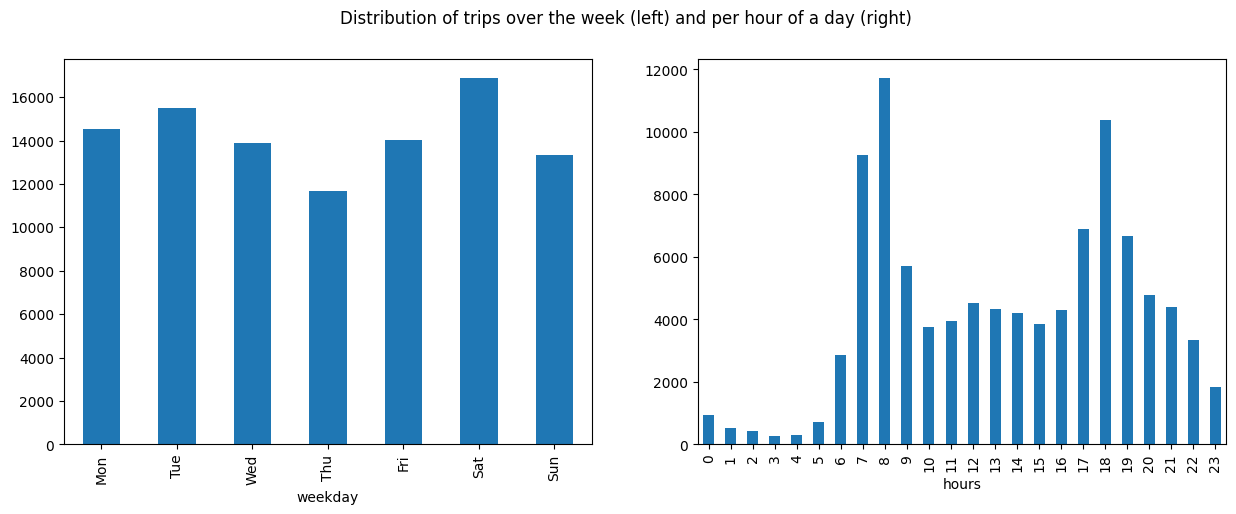

In [15]:
weekday_names = {0:'Mon',1:'Tue',2:'Wed',3:'Thu',4:'Fri',5:'Sat',6:'Sun',}
order = weekday_names.values()

df['weekday'] = df['START_TIME'].dt.dayofweek
df['weekday'] = df['weekday'].replace(weekday_names)
df['hours'] = df['START_TIME'].dt.hour

weekdays = df.groupby('weekday').size().to_frame('count').loc[order].reset_index()
hours = df.groupby('hours').size().to_frame('count').reset_index()

fig,ax = plt.subplots(ncols=2, figsize=(15,5))
weekdays.plot.bar(ax=ax[0], x='weekday',y='count',legend = False)
hours.plot.bar(ax=ax[1], x='hours',y='count',legend=False)
plt.suptitle('Distribution of trips over the week (left) and per hour of a day (right)')

We will add a column for whether a trip occurs on a weekday or the weekend.

In [16]:
# Add weekday column
df.loc[:, 'IS_WEEKDAY'] = df['START_TIME'].dt.dayofweek < 5

In [17]:
pd.DataFrame({
    'count': df.count(),
    'min': df.min(),
    'max': df.max()
})

,count,min,max
Unnamed: 0,99883,13,9980889
_id,99883,6235d85fd9eb0867d7831fb3,62360a21d9eb0867d71b6b7f
START_TIME,99883,2021-07-30 07:48:59,2021-08-07 19:07:17
START_LAT,99883,22.422615,22.945366
END_TIME,99883,2021-07-30 08:46:34,2021-08-07 19:11:50
END_LNG,99883,113.751865,114.441227
USER_ID,99883,000084648220169e446943**********,ffffde30ff61ecbdcc54eb**********
START_LNG,99883,113.763582,114.464048
END_LAT,99883,22.435993,22.819879
weekday,99883,Fri,Wed


Next, let's visualize the shape files in our dataset, starting with the shape file for Shenzhen.

Reading a shapefile with geopandas (imported as gpd) returns a GeoDataFrame, not a regular pandas DataFrame. A GeoDataFrame behaves like a normal DataFrame (same indexing, filtering, .groupby(), etc.) but has one extra column, geometry, which holds each row's actual shape (a point, line, or polygon with real-world coordinates). This is what lets us plot, measure distances, and spatially join our data directly, which a regular DataFrame can't do on its own.

In [18]:
# Read shape file
shenzhen = gpd.read_file("data/Shenzhen Bike-Share Data/shenzhen/shenzhen.shp")

Text(214.51131188765714, 0.5, 'Latitude')

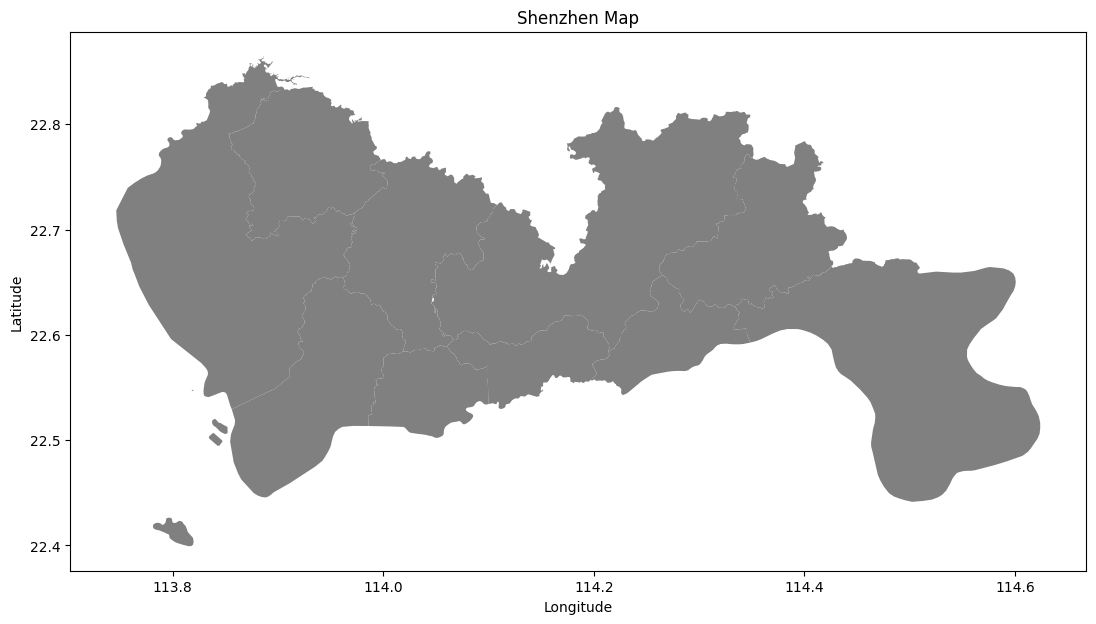

In [19]:
# Visualize
fig,ax = plt.subplots(figsize=(15,7))
shenzhen.plot(ax=ax,color='gray')
ax.set_title('Shenzhen Map')
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

We overlap the trip starting points and ending points on the map above. To do this, we first create GeoDataFrames from the trip start and end coordinates from the data we processed above, then plot the trip start/end GeoDataFrame together with the Shenzhen GeoDataFrame. This yields the two plots below:

In [20]:
# Create geopandas dataframes for start and end points separately
gdf_start = gpd.GeoDataFrame(df, geometry=[Point(xy) for xy in zip(df['START_LNG'], df['START_LAT'])],crs=4326)
gdf_end = gpd.GeoDataFrame(df, geometry=[Point(xy) for xy in zip(df['END_LNG'], df['END_LAT'])],crs=4326)

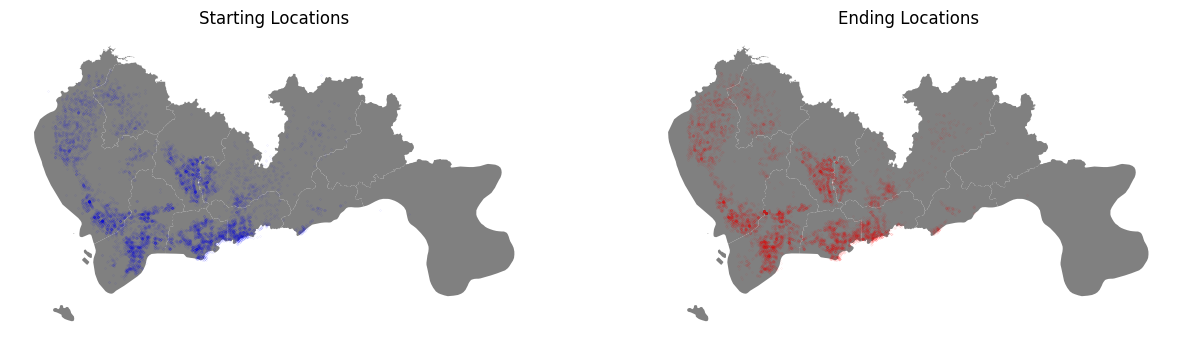

In [21]:
# Visualize Starting Locations
fig,ax = plt.subplots(ncols=2,figsize=(15,7))
shenzhen.plot(ax=ax[0],color='gray')
gdf_start.sample(10000).plot(ax=ax[0],color='blue',marker='o',markersize=0.001)
ax[0].set_title('Starting Locations')
ax[0].set_axis_off()

shenzhen.plot(ax=ax[1],color='gray')
gdf_end.sample(10000).plot(ax=ax[1],color='red',marker='o',markersize=0.001)
ax[1].set_title('Ending Locations')
ax[1].set_axis_off()


Notice that the start and end plots look similar. In fact what we are plotting here are actually bike stands from which bikers borrow and return bikes. We can now investigate the POIs (restaurants, stadiums, offices, stations, etc.) that exist around these bike stands to get a sense for where the bikers are headed.

The process of loading and visualizing the POI data from shape files is similar to above. Again, since loading all the POI shape files and plotting them will be time-consuming, we load a subset of the POI categories.   
Before we can select the POI categories we are interested in, we need to find out what POI categories exist. This information is stored in the amap_poicode.xlsx file in the ShenzhenPOI folder.

In [22]:
# Find all POI types
poi_types_df = pd.read_excel("data/Shenzhen Bike-Share Data/ShenzhenPOI/amap_poicode.xlsx")
poi_types_df.head()

/usr/local/lib/python3.13/dist-packages/openpyxl/worksheet/header_footer.py:48: UserWarning: Cannot parse header or footer so it will be ignored
  warn("""Cannot parse header or footer so it will be ignored""")


,序号,NEW_TYPE,大类,中类,小类,Big Category,Mid Category,Sub Category
0,1,10000,汽车服务,汽车服务相关,汽车服务相关,Auto Service,Automobile Service Related,Automobile Service Related
1,2,10100,汽车服务,加油站,加油站,Auto Service,Filling Station,Filling Station
2,3,10101,汽车服务,加油站,中国石化,Auto Service,Filling Station,Sinopec
3,4,10102,汽车服务,加油站,中国石油,Auto Service,Filling Station,PetroChina
4,5,10103,汽车服务,加油站,壳牌,Auto Service,Filling Station,Shell


Each POI category is further sub-divided into smaller categories. Let's assume that we are not interested in the sub-categories. We will need to find all the unique categories stored in the "Big Category" attribute above.

Note: You might be curious about the Chinese columns, 序号, 大类, 中类, and 小类. The first two are just a row index and AMap's internal POI code; the last three are the original three-level category hierarchy (broad to specific), translated directly into the Big Category, Mid Category, and Sub Category columns next to them. We'll use the English columns going forward.

In [23]:
unique_poi_types = poi_types_df['Big Category'].drop_duplicates().values

print(unique_poi_types)

['Auto Service' 'Auto Dealers' 'Auto Repair' 'Motorcycle Service'
 'Food & Beverages' 'Shopping' 'Daily Life Service' 'Sports & Recreation'
 'Medical Service' 'Accommodation Service' 'Tourist Attraction'
 'Commercial House' 'Governmental Organization & Social Group'
 'Science/Culture & Education Service' 'Culture & Education'
 'Transportation Service' 'Finance & Insurance Service' 'Enterprises'
 'Road Furniture' 'Place Name & Address' 'Public Facility'
 'Incidents and Events' 'Indoor facilities' 'Pass Facilities']


Next, we have to sanitize the category names by removing whitespaces and some special characters. We have to do this because the shape file names corresponding to these categories contain sanitized category names and we want to  select the shape files for the categories we are interested in.

In [24]:
for i, poi in enumerate(unique_poi_types):
  for c in [' ', '&', '/']:
     unique_poi_types[i] = unique_poi_types[i].replace(c, '')

print(unique_poi_types)

['AutoService' 'AutoDealers' 'AutoRepair' 'MotorcycleService'
 'FoodBeverages' 'Shopping' 'DailyLifeService' 'SportsRecreation'
 'MedicalService' 'AccommodationService' 'TouristAttraction'
 'CommercialHouse' 'GovernmentalOrganizationSocialGroup'
 'ScienceCultureEducationService' 'CultureEducation'
 'TransportationService' 'FinanceInsuranceService' 'Enterprises'
 'RoadFurniture' 'PlaceNameAddress' 'PublicFacility' 'IncidentsandEvents'
 'Indoorfacilities' 'PassFacilities']


For this tutorial, let's assume that we are interested in medical and transportation services, and sports and rec facilities only.

In [25]:
# Define POI categories we want to select
poi_cat = ['SportsRecreation', 'TransportationService', 'MedicalService']

In [26]:
# Set path to shapefile directory
poi_dir_path = '/content/data/Shenzhen Bike-Share Data/ShenzhenPOI/ShapeFile'

# Load poi shape files
shp_files = []
for file_path in os.listdir(poi_dir_path):
  if file_path.endswith(".shp"):
    for cat in poi_cat:
      if cat in file_path:
        shp_file = gpd.read_file(os.path.join(poi_dir_path, file_path))
        shp_file['POI_TYPE'] = cat
        shp_files.append(shp_file)
        continue

In [27]:
# Create geo dataframe from all POIs
poi_gdf = pd.concat(shp_files).pipe(gpd.GeoDataFrame)
poi_gdf.describe(include='all')

,geometry,POI_TYPE
count,80237,80237
unique,80009,3
top,POINT (113.96224097276098 22.70804055426153),TransportationService
freq,4,35387


To visually analyze the data we now use the "explore" function from geopandas. An easy way to quickly inspect geopandas geometries on any kind of basemap.

In [28]:
poi_gdf.sample(1000).explore('POI_TYPE', tiles='CartoDB positron')

We have a good distribution of our selected POIs around the trip starting and ending points. So we can hope that we can model some kind of relationship between the trips and these POIs. But first, we have to save our POI geodataframe so that we can reuse it later.

In [29]:
# Prepare directory to save poi geodataframe
compiled_poi_path = '/content/data/Shenzhen Bike-Share Data/poi_compiled'

# Delete folder if it already exists
if os.path.exists(compiled_poi_path):
  shutil.rmtree(compiled_poi_path)

os.mkdir(compiled_poi_path)

In [30]:
# Save poi gdf
poi_gdf.to_file(compiled_poi_path + '/compiled.shp', encoding='UTF-8')

<a name="methodology"></a>
# Methodology

Our goal is to investigate the influence of POIs on trip destinations.

To do this, we first count the number of POIs and the number of trips ending in each location, and then regress the trip counts on the POI counts to study how they are related. We use Uber's hexagonal grid called [H3](https://github.com/uber/h3) and its add-on for (Geo)Pandas [h3pandas](https://h3-pandas.readthedocs.io/en/latest/index.html) and count the number of POIs and trips in each grid cell.

The great thing about H3 is that it has a unique indexing system around the world (i.e. the cell id `88411cd68dfffff` always corresponds to the same location) and supports multiple spatial resolutions (see [here](https://h3geo.org/docs/core-library/restable)). So we can try different grid sizes for our analysis and further aggregate the data with little additional effort. For the resolution `8` that we use, each grid cell has an area of [0.74 km2](https://h3geo.org/docs/core-library/restable#average-area-in-km2).

**A modeling simplification worth flagging:** we don't have ground-truth data on where official bike stands are, so we approximate this using grid cells where at least one trip ends. This likely undercounts low-usage areas (including possibly underserved neighborhoods) which matters if this workflow were used to guide real infrastructure decisions.

## POI and Trip Counts

In [31]:
import h3pandas

# Convert trip DataFrame to a GeoDataFrame with the geometry describing the trip destination
gdf = gpd.GeoDataFrame(df, crs='EPSG:4326', geometry=gpd.points_from_xy(df['END_LNG'], df['END_LAT']))

# Create a hexagonal grid using Uber's H3 library and count the number of trips ending in each grid cell
trips = gdf[['_id', 'geometry']].h3.geo_to_h3_aggregate(resolution=8, operation='count')
trips = trips.rename(columns={'_id': 'count'})

# Visualize trip destinations
trips.explore('count')

In [32]:
# Count number of POIs per type in each hexagonal grid cell
poi_counts = poi_gdf.groupby('POI_TYPE').apply(lambda x: x.h3.geo_to_h3_aggregate(resolution=8, operation='count'))
poi_counts = poi_counts.rename(columns={'POI_TYPE': 'count'}).reset_index()

# Reshape dataframe so that each POI type count is its own column ("long" to "wide" format)
poi_counts = poi_counts.pivot(index='h3_08', columns='POI_TYPE', values='count')
poi_counts

POI_TYPE,MedicalService,SportsRecreation,TransportationService
h3_08,,,
88411c0001fffff,15.0,6.0,4.0
88411c0003fffff,4.0,5.0,5.0
88411c0005fffff,3.0,NaN,4.0
88411c0007fffff,NaN,NaN,1.0
88411c0009fffff,23.0,7.0,11.0
...,...,...,...
88411cd687fffff,1.0,1.0,4.0
88411cd68dfffff,NaN,6.0,3.0
88411cd691fffff,NaN,NaN,5.0


In our analysis we want to only consider grid cells where shared-bike stands exist.
We don't have this data at hand, so as a workaround we only consider grid cells where at least one trip ends.

In [33]:
# Merge the POI counts to the grid cells where trip end and fill NaN
trips = trips.join(poi_counts).fillna(0)

<a name="lr"></a>

## Linear Regression
Now, let's try to find a relationship between the trip destinations and POI counts. For now, we will assume that the two are linearly related.

We fit a LinearRegression model from sklearn.linear_model and try to find a linear relationship between the POI and trip counts we determined for each location in the grid.

In [34]:
for poi_type in ['SportsRecreation', 'TransportationService', 'MedicalService']:
    y = trips['count']
    X = trips[[poi_type]]

    # Perform linear regression
    lm = LinearRegression()
    lm.fit(X, y)

    # Print the results
    print(poi_type)
    print(f'Coefficients: {lm.coef_[0]:.1f}')
    print(f'Intercept: {lm.intercept_:.1f}')
    print(f'R-squared: {lm.score(X, y):.3f}')
    print()

SportsRecreation
Coefficients: 3.6
Intercept: 31.4
R-squared: 0.320

TransportationService
Coefficients: 2.8
Intercept: 9.5
R-squared: 0.395

MedicalService
Coefficients: 2.4
Intercept: 31.4
R-squared: 0.259



The R-squared score represents the correlation between POI and trip ending counts. The higher the correlation, the better our model is at representing the relationship between POIs and trip endings.

Now, let's combine all predictors and see what predictive performance we can reach.

In [35]:
X = trips[['SportsRecreation', 'TransportationService', 'MedicalService']]
y = trips['count']

# Perform linear regression
lm = LinearRegression()
lm.fit(X, y)
y_pred_lm = lm.predict(X)

print(f'Coefficients: {lm.coef_}')
print(f'Intercept: {lm.intercept_:.1f}')
print(f'R-squared: {lm.score(X, y):.3f}')

Coefficients: [ 1.32531635  2.21534129 -0.18060387]
Intercept: 10.6
R-squared: 0.409


<a name="gbdt"></a>

## Gradient boosting decision trees

Assuming that POI densities linearly influence trip destination counts is a strong assumption and may not always hold in reality. Therefore let's try another model that does not make any parametric assumptions on the relationship between the features and the outcome, for example a gradient boosting decision tree ensemble.

### Exercise 1

<a name="task-xgboost"></a>

⭐ **YOUR TURN!:** Try to use the [XGBoost](https://xgboost.readthedocs.io/en/latest/python/python_api.html) regressor (`XGBRegressor`) to model the relationship.

In [36]:
model = XGBRegressor() ## YOUR CODE HERE
model.fit(X, y)
y_pred_xgb = model.predict(X) ## YOUR CODE HERE

r2 = r2_score(y, y_pred_xgb) ## YOUR CODE HERE
print(f'R-squared: {r2:.3f}')

R-squared: 0.958


#### Solution

In [44]:
model = XGBRegressor()
model.fit(X, y)
y_pred_xgb = model.predict(X)

r2 = r2_score(y, y_pred_xgb)
print(f'R-squared: {r2:.3f}')

R-squared: 0.958


<a name="gnn"></a>

## Graph Neural Network (GNN)
Our trip destinations follow some clear spatial patterns. This is something simple linear models cannot capture. Instead, we can deploy a model with the capacity to account for and learn from spatial dependencies. For example, a GNN.

First, we need to construct an input graph. This can be done by using the spatial coordinates (latitude and longitude) of our grid cells to obtain a $k$-nearest-neighbor graph.

In [37]:
from torch_geometric.nn import knn_graph
from torch_geometric.data import Data
from torch_geometric.nn import GCNConv, GATConv, SAGEConv
import torch
import torch.nn as nn
import torch.utils.data
import torch.nn.functional as F

c = trips.geometry.centroid.get_coordinates()
X = trips[['SportsRecreation', 'TransportationService', 'MedicalService']]
y = trips['count']

# Convert to PyTorch data format
c_tensor = torch.tensor(c.values, dtype=torch.float)
X_tensor = torch.tensor(X.values, dtype=torch.float)
y_tensor = torch.tensor(y.values, dtype=torch.float)

# Determine neighboring grid cells
k = 5
edge_index = knn_graph(c_tensor, k=k, loop=False)

graph_data = Data(x=X_tensor, y=y_tensor, edge_index=edge_index, pos=c_tensor)

/tmp/ipykernel_903/485592677.py:9: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  c = trips.geometry.centroid.get_coordinates()


We now define our GNN. Let's start with a simple Graph Convolutional Network (GCN) with two convolutional layers and a linear prediction head.

In [38]:
class GCN(nn.Module):
    """
        A simple GCN with two convolutional layers
    """
    def __init__(self, num_features_in=3, num_features_out=1, hidden_dim=32, dropout=False):
        super(GCN, self).__init__()
        self.conv1 = GCNConv(num_features_in, hidden_dim)
        self.conv2 = GCNConv(hidden_dim, hidden_dim)
        self.fc = nn.Linear(hidden_dim, num_features_out)
        self.dropout = dropout

    def forward(self, x, edge_index):
        x = x.float()
        h1 = F.relu(self.conv1(x, edge_index))
        if self.dropout:
          h1 = F.dropout(h1, training=self.training)
        h2 = F.relu(self.conv2(h1, edge_index))
        if self.dropout:
          h2 = F.dropout(h2, training=self.training)
        output = self.fc(h2)
        return output

Now we need to set our training hyperparameters: How many epochs do we want to train? What learning rate and which optimizer do we want to use? Which loss function do we want to use? Which hyperparameters (e.g. hidden dimensions) should our GNN have?

In [39]:
lr = 1e-2
n_epochs = 1000
print_freq = 100

model = GCN(num_features_in=3, num_features_out=1, hidden_dim=32, dropout=False)
loss_fun = nn.MSELoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=lr)

Let's train the GNN using backpropagation!

In [40]:
# Training loop
it_counts = 0
for epoch in range(n_epochs):
  it_counts += 1
  model.train()
  out = model(graph_data.x.float(), graph_data.edge_index)
  optimizer.zero_grad()
  loss = loss_fun(graph_data.y.float().reshape(-1), out.reshape(-1))
  loss.backward()
  optimizer.step()
  if it_counts % print_freq == 0:
    print(f'Loss: {loss.item():.1f}')

Loss: 7118.6
Loss: 6727.4
Loss: 6471.9
Loss: 6394.2
Loss: 6356.2
Loss: 6313.2
Loss: 6266.6
Loss: 6233.2
Loss: 6215.5
Loss: 6204.4


Training is done! We can obtain predictions and compute the R-squared score.

In [41]:
with torch.no_grad():
  model.eval()
  y_pred_gnn = model(graph_data.x.float(), graph_data.edge_index)

gnn_r2 = r2_score(graph_data.y, y_pred_gnn)
print(f'GNN R-squared: {gnn_r2:.3f}')


GNN R-squared: 0.492


<a name="results"></a>
# Results



How do predictions made by the linear model, XGBoost and the GNN compare?

**Answer:**
1. **Linear model**: predictions appear smoother and less able to reproduce the detailed variations in the true map.
2. **XGBoost**: Matches the true spatial pattern more closely and captures more of the local variation than the linear model.
3. **GNN**: Also closely resembles the true map and captures spatial patterns well.

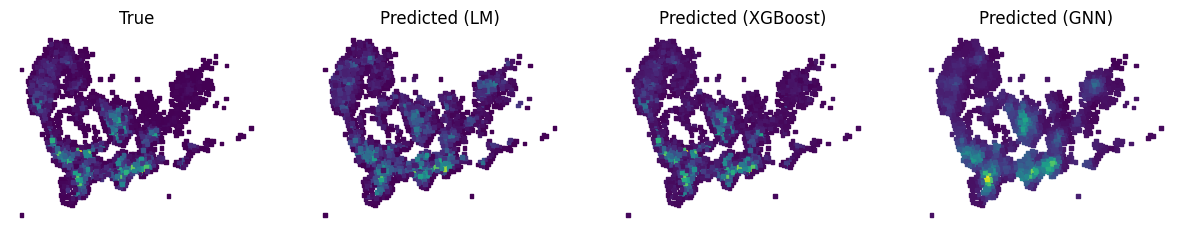

In [47]:
fig, ax = plt.subplots(1, 4, figsize=(15, 2.5))
ax[0].scatter(c['x'], c['y'], c=graph_data.y.reshape(-1), cmap='viridis', marker="s", s=7)
ax[0].set_title('True')
ax[0].set_axis_off()

ax[1].scatter(c['x'], c['y'], c=y_pred_lm.reshape(-1), cmap='viridis', marker="s", s=7)
ax[1].set_title('Predicted (LM)')
ax[1].set_axis_off()

ax[2].scatter(c['x'], c['y'], c=y_pred_xgb.reshape(-1), cmap='viridis', marker="s", s=7) # comment in after solving exercise 1
ax[2].set_title('Predicted (XGBoost)')
ax[2].set_axis_off()

ax[3].scatter(c['x'], c['y'], c=y_pred_gnn.detach().reshape(-1), cmap='viridis', marker="s", s=7)
ax[3].set_title('Predicted (GNN)')
ax[3].set_axis_off()

Are there spatial patterns visible in the prediction residuals / errors?

**Answer:**
1. The errors are not randomly distributed; nearby regions tend to have similar error magnitudes, forming spatial clusters.
2. The **LM** residuals show relatively broad, smooth spatial patterns, suggesting that the linear model misses some spatially varying relationships.
3. **XGBoost** shows a more consistent spatial pattern across the region, with fewer abrupt local variations.
4. **GNN** also shows spatially coherent errors, but captures local spatial structure somewhat differently.

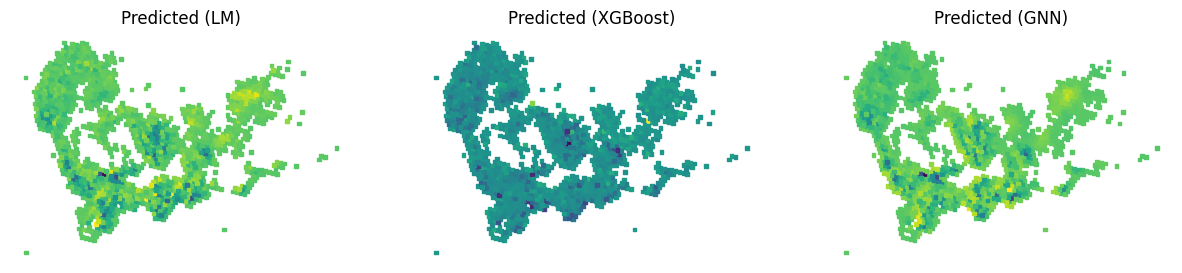

In [48]:
y_true = graph_data.y.reshape(-1).numpy()

fig, ax = plt.subplots(1, 3, figsize=(15, 3))
ax[0].scatter(c['x'], c['y'], c=y_pred_lm.reshape(-1) - y_true, cmap='viridis', marker="s", s=7)
ax[0].set_axis_off()
ax[0].set_title('Predicted (LM)')

ax[1].scatter(c['x'], c['y'], c=y_pred_xgb.reshape(-1) - y_true, cmap='viridis', marker="s", s=7) # comment in after solving exercise 1
ax[1].set_title('Predicted (XGBoost)')
ax[1].set_axis_off()

ax[2].scatter(c['x'], c['y'], c=y_pred_gnn.detach().reshape(-1) - y_true, cmap='viridis', marker="s", s=7)
ax[2].set_title('Predicted (GNN)')
ax[2].set_axis_off()

### Out-of-sample / generalization performance

To get a more realistic idea of how well (or not) our models perform out-of-sample, let's split our data into **training**, **validation**, and **test** sets.

We use the **validation set** to tune the hyperparameters, monitor training progress and detect overfitting or perform early stopping, and the **test set** to evaluate the final model on unseen data. If we were to use the validation set to evaluate the final model, we would overestimate the predictive performance since the model is likely to perform disproportionately well on the data used to tune the hyperparameters. Having a reliable estimate of out-of-sample predictive performance is key to assessing applicability to real-world use cases.

In [49]:
from sklearn.model_selection import train_test_split

# Split into train (60%), validation (20%), and test (20%) set
X_train, X_test, y_train, y_test, c_train, c_test = train_test_split(X, y, c, test_size=0.2, random_state=0)
X_train, X_val, y_train, y_val, c_train, c_val = train_test_split(X_train, y_train, c_train, test_size=0.25, random_state=0) # 0.25 x 0.8 = 0.2

Let's plot the train, validation and test set.

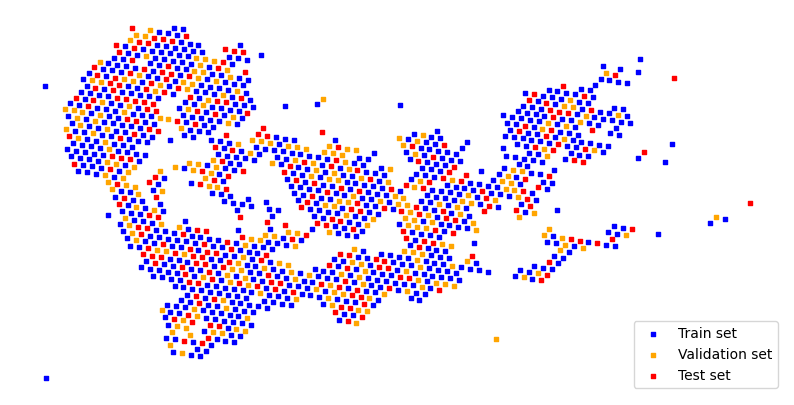

In [50]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.scatter(c_train['x'], c_train['y'], c='blue', marker="s", s=10, label="Train set")
ax.scatter(c_val['x'], c_val['y'], c='orange', marker="s", s=10, label="Validation set")
ax.scatter(c_test['x'], c_test['y'], c='red', marker="s", s=10, label="Test set")
ax.legend()
ax.set_axis_off()

**Tracking energy use:** as a best practice, we use [CodeCarbon](https://codecarbon.io/) to measure the energy consumption and estimated CO2 emissions of training our models.

This is a small demo model, so the absolute numbers will be tiny — the useful takeaway is comparing the three models to each other, not the exact values. The same logic applies at production scale, where the energy cost of a more complex model is a tradeoff worth weighing against its accuracy gains.

In [51]:
!pip install -q codecarbon
from codecarbon import EmissionsTracker

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 402.7/402.7 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.6/155.6 kB 11.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.2/53.2 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.0/8.0 MB 63.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 83.3 MB/s eta 0:00:00


Now, let's train all models again and evaluate them on unseen data.

In [52]:
tracker_lm = EmissionsTracker(measure_power_secs=1, save_to_file=False, log_level='error')
tracker_lm.start()

lm = LinearRegression()
lm.fit(X_train, y_train)
y_pred_train_lm = lm.predict(X_train)
y_pred_test_lm = lm.predict(X_test)

lm_train_r2 = r2_score(y_train, y_pred_train_lm)
lm_test_r2 = r2_score(y_test, y_pred_test_lm)
print(f"LM - Train R-squared: {lm_train_r2:.3f}")
print(f"LM - Test R-squared: {lm_test_r2:.3f}")


emissions_lm = tracker_lm.stop()
print(f'Estimated emissions (LM): {emissions_lm:.8f} kg CO2eq')


[codecarbon WARNING @ 17:08:34] Multiple instances of codecarbon are allowed to run at the same time.


LM - Train R-squared: 0.388
LM - Test R-squared: 0.438
Estimated emissions (LM): 0.00000007 kg CO2eq


In [53]:
tracker_xgb = EmissionsTracker(measure_power_secs=1, save_to_file=False, log_level='error')
tracker_xgb.start()

xgb_model = XGBRegressor(random_state=0)
xgb_model.fit(X_train, y_train, verbose=False, eval_set=[(X_train, y_train), (X_val, y_val)])
y_pred_train_xgb = xgb_model.predict(X_train)
y_pred_test_xgb = xgb_model.predict(X_test)

xgb_train_r2 = r2_score(y_train, y_pred_train_xgb)
xgb_test_r2 = r2_score(y_test, y_pred_test_xgb)
print(f'XGBoost - Train R-squared: {xgb_train_r2:.3f}')
print(f'XGBoost - Test R-squared: {xgb_test_r2:.3f}')

emissions_xgb = tracker_xgb.stop()
print(f'Estimated emissions (XGBoost): {emissions_xgb:.8f} kg CO2eq')


XGBoost - Train R-squared: 0.976
XGBoost - Test R-squared: 0.171
Estimated emissions (XGBoost): 0.00000072 kg CO2eq


We can inspect the training progress and see how the model performance changes over time with additional trees or training epochs to detect under- and overfitting.

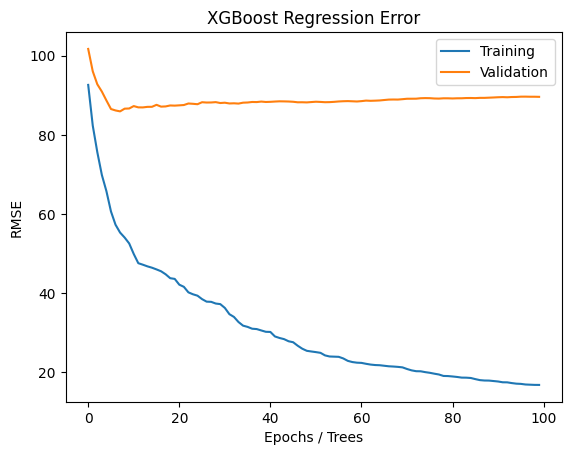

In [54]:
# Retrieve training performance metrics
results = xgb_model.evals_result()
error_train = results['validation_0']['rmse']
error_test = results['validation_1']['rmse']

# Plot performance metrics
_, ax = plt.subplots(1)
epochs = len(error_train)
x_axis = range(0, epochs)
ax.plot(x_axis, error_train, label='Training')
ax.plot(x_axis, error_test, label='Validation')
ax.set_xlabel('Epochs / Trees')
ax.set_ylabel('RMSE')
ax.set_title('XGBoost Regression Error')
ax.legend()


We can clearly see that the training error continues to decrease, while the validation error starts to increase slightly after 10 trees, indicating a slight overfitting. Consequently, we could decrease the `n_estimators` hyperparameter to use only 10 trees or perform some form of regularization to mitigate the overfitting.

In [55]:
tracker_gnn = EmissionsTracker(measure_power_secs=1, save_to_file=False, log_level='error')
tracker_gnn.start()

torch.manual_seed(1886298579725472513) # some seed to ensure reproducibility

lr = 1e-1
n_epochs = 1000
print_freq = 100

losses_train = []
losses_val = []

c_train_t = torch.tensor(c_train.values, dtype=torch.float)
X_train_t = torch.tensor(X_train.values, dtype=torch.float)
y_train_t = torch.tensor(y_train.values, dtype=torch.float)

c_val_t = torch.tensor(c_val.values, dtype=torch.float)
X_val_t = torch.tensor(X_val.values, dtype=torch.float)
y_val_t = torch.tensor(y_val.values, dtype=torch.float)

c_test_t = torch.tensor(c_test.values, dtype=torch.float)
X_test_t = torch.tensor(X_test.values, dtype=torch.float)
y_test_t = torch.tensor(y_test.values, dtype=torch.float)

edge_index_train = knn_graph(c_train_t, k=k, loop=False)
edge_index_val = knn_graph(c_val_t, k=k, loop=False)
edge_index_test = knn_graph(c_test_t, k=k, loop=False)

graph_data_train = Data(x=X_train_t, y=y_train_t, edge_index=edge_index_train, pos=c_train_t)
graph_data_val = Data(x=X_val_t, y=y_val_t, edge_index=edge_index_val, pos=c_val_t)
graph_data_test = Data(x=X_test_t, y=y_test_t, edge_index=edge_index_test, pos=c_test_t)

model = GCN(num_features_in=3, num_features_out=1, hidden_dim=32, dropout=False)
loss_fun = nn.MSELoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=lr)

it_counts = 0
for epoch in range(n_epochs):
  it_counts += 1
  model.train()
  out = model(graph_data_train.x.float(), graph_data_train.edge_index)
  optimizer.zero_grad()
  loss_train = loss_fun(graph_data_train.y.float().reshape(-1), out.reshape(-1))

  out_test = model(graph_data_val.x.float(), graph_data_val.edge_index)
  loss_val = loss_fun(graph_data_val.y.float().reshape(-1), out_test.reshape(-1))
  losses_train.append(loss_train.item())
  losses_val.append(loss_val.item())

  loss_train.backward()
  optimizer.step()
  if it_counts % print_freq == 0:
    print(f'Train loss: {loss_train.item():.1f}, Validation loss: {loss_val.item():.1f}')

emissions_gnn = tracker_gnn.stop()
print(f'Estimated emissions (GNN): {emissions_gnn:.8f} kg CO2eq')


Train loss: 7006.6, Validation loss: 9466.7
Train loss: 7026.9, Validation loss: 9451.4
Train loss: 6792.9, Validation loss: 9698.0
Train loss: 6660.5, Validation loss: 9376.9
Train loss: 6589.0, Validation loss: 9108.6
Train loss: 6575.5, Validation loss: 9572.8
Train loss: 6555.5, Validation loss: 10300.2
Train loss: 6381.4, Validation loss: 9466.8
Train loss: 6395.7, Validation loss: 10472.6
Train loss: 6274.1, Validation loss: 9454.5
Estimated emissions (GNN): 0.00003214 kg CO2eq


Let's compare the estimated emissions across the three models we trained. Keep in mind these are tiny demo-scale numbers — the point is to build the habit of checking, not the absolute magnitude here.

In [56]:
import pandas as pd

emissions_comparison = pd.DataFrame({
    'model': ['Linear Regression', 'XGBoost', 'GNN'],
    'estimated_emissions_kg_co2eq': [emissions_lm, emissions_xgb, emissions_gnn]
})
emissions_comparison

,model,estimated_emissions_kg_co2eq
0,Linear Regression,7.138568e-08
1,XGBoost,7.210394e-07
2,GNN,3.213828e-05


In [57]:
with torch.no_grad():
  model.eval()
  y_pred_train_gnn = model(graph_data_train.x.float(), graph_data_train.edge_index)
  y_pred_test_gnn = model(graph_data_test.x.float(), graph_data_test.edge_index)

gnn_train_r2 = r2_score(y_train, y_pred_train_gnn)
gnn_test_r2 = r2_score(y_test, y_pred_test_gnn)
print(f"GNN - Train R-squared: {gnn_train_r2:.3f}")
print(f"GNN - Test R-squared: {gnn_test_r2:.3f}")

GNN - Train R-squared: 0.481
GNN - Test R-squared: 0.355


Let's visualize the training and validation loss again to detect under- and overfitting.

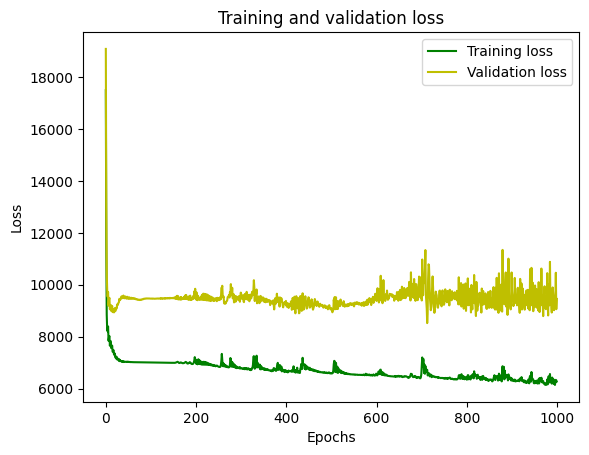

In [58]:
plt.clf()
epochs = list(range(n_epochs))
plt.plot(epochs, losses_train, 'g', label='Training loss')
plt.plot(epochs, losses_val, 'y', label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()


We see a similar pattern as before: The validation loss increases again after some time, indicating that the out-of-sample predictive performance of our model would be better if we had stopped the training earlier.

<a name="discussion"></a>

# Discussion

In [59]:
r_squared = {
    'Linear reg.': {
        'Train': lm_train_r2,
        'Test': lm_test_r2,
        },
    'XGBoost': {
        'Train': xgb_train_r2,
        'Test': xgb_test_r2,
        },
    'GNN': {
        'Train': gnn_train_r2,
        'Test': gnn_test_r2,
        },
}

pd.DataFrame(r_squared).round(2)

,Linear reg.,XGBoost,GNN
Train,0.39,0.98,0.48
Test,0.44,0.17,0.35


<a name="take-aways"></a>

### What are the main take-aways from our model comparison?

* **Linear vs. non-parametric relationships:** A machine learning model does not necessarily outperform traditional statistical models such as linear regression. In particular, if the relationship between the features and the outcome is approximately linear, a linear regression will most likely outperform machine learning models and provide more reliable results (the risk of overfitting is much lower due to the strong parametric assumptions made beforehand). However, if the relationship is characterized by nonlinearities and threshold effects, a machine learning model is often the better choice.
* **Model complexity:** A deep neural network will not always outperform simpler models. Especially when training data is scarce, less complex models, which are faster to train and require less training data, have an advantage. Also, on tabular data, tree-based models such as RandomForest, XGBoost, or LightGBM often (still) outperform neural networks. Our model comparison results here are preliminary, as we used only a fraction of the available data and neglected other features of interest that may have a non-linear impact (e.g. local bicycle infrastructure) and temporal patterns in the data.
* **Choose your hyperparameters wisely:** Always evaluate your machine learning model on unseen data to avoid overoptimistic performance estimates. Especially for neural networks, use a dedicated validation set to optimize your hyperparameters and detect overfitting.

* **Energy cost isn't negligible at scale:** even on this small demo, you likely saw the GNN take noticeably more energy to train than the linear model for a modest gain in R-squared. At production scale, this tradeoff is a real design decision, not just an accuracy question.

### Reflection: Would this model work in your city?

Before reading the Limitations section below, take a minute to think: if you tried to apply this *trained* model as-is to a city you know well, what would you expect to break first?
Consider: Does your city have similarly dense bike-share/transit integration? Are POI categories like "medical service" or "sports facility" distributed similarly relative to housing? Would the trip data collection process (which operator, which time period) matter?

There's no single right answer here, what matters is asking the question before deployment.

**Answer:** If I applied this trained model directly to *Kolkata*, I would expect some loss in performance because the model may have been trained on a different city's urban structure and travel patterns.

1. Different urban density and structure: Kolkata has a mix of very dense central areas, residential neighborhoods, and less dense outskirts, which may differ from the training city's spatial patterns.
2. Transportation system: Kolkata has extensive bus, metro, suburban rail, tram, and ferry networks, alongside walking and cycling. The relationship between these modes and bike-share trips may therefore differ from the training data.
3. POI distribution: Places such as markets, schools, hospitals, offices, and residential areas may have different spatial relationships in Kolkata.
4. Travel behavior: Commuting patterns and preferences for public transport, walking, cycling, and private vehicles can vary substantially between cities.
5. Time and data collection: Traffic, weather, festivals, holidays, and the period during which trip data were collected could all affect the model's predictions.

### Can we improve the model performance further?

### Exercise 2

<a name="task-GNN-tune"></a>

⭐ **YOUR TURN!**

Try to improve the predictive performance (Test R2) of the GNN above by tuning its hyperparameters and implement early stopping<sup>1</sup>:
* **Learning rate**: Find a good balance between fast convergence during training and a stable detection of minima (e.g. validation loss should not jump around)
* **Epochs**: The number of epochs for the GNN determines how many times the entire training dataset is passed through the network to find the optimal weights (intuition: too few epochs may not be sufficient to capture all relevant information in the training data and result in underfitting, too many epochs may result in overfitting)
* **Early stopping**: A good way to find a reasonable number of epochs is to stop training when the validation error stops decreasing or even increases again, a technique called early stopping.
* **Model complexity and architecture**: Generally said, the more parameters / weights a model has, the more information it can potentially capture. Different architectures help to capture different types of data (e.g. recurrent layers are great for temporal data, convolution layers are great for spatial data or images, attention layers are great for relational and sequential data). Try to increase the model complexity to improve the predictive performance, without running into the overfitting regime. For the GNN you can, for example, increase the number of neurons in the hidden layer (`hidden_dim`) or try a more complex model architecture (e.g. `GATConv` or `SAGEConv`).


<sup>1</sup> *The goal of this task is to get a feeling for how different hyperparameters influence the training progress and how overfitting can be spotted and mitigated. There is no need to actually find the best performing hyperparameters - also considering that we intentionally use only a subset of the data, a relatively simple model architecture and a simplified task to ensure fast training. In this sense, the task is rather exploratory and does not have a single solution.*

In [60]:
# Learning rate and epochs
lr = 1e-4
n_epochs = 2000

# Reinitialize the model and optimizer
model = GCN(
    num_features_in=3,
    num_features_out=1,
    hidden_dim=64,
    dropout=False
)
optimizer = torch.optim.AdamW(model.parameters(), lr=lr)

# Early stopping
early_stopping_patience = 10

best_loss = np.inf
best_model = None
patience_counter = 0

for epoch in range(n_epochs):
    model.train()

    out = model(
        graph_data_train.x.float(),
        graph_data_train.edge_index
    )

    loss_train = loss_fun(
        graph_data_train.y.float().reshape(-1),
        out.reshape(-1)
    )

    optimizer.zero_grad()
    loss_train.backward()
    optimizer.step()

    # Validation
    model.eval()
    with torch.no_grad():
        out_val = model(
            graph_data_val.x.float(),
            graph_data_val.edge_index
        )

        loss_val = loss_fun(
            graph_data_val.y.float().reshape(-1),
            out_val.reshape(-1)
        ).item()

    # Save best model
    if loss_val < best_loss:
        best_loss = loss_val
        patience_counter = 0
        best_model = model.state_dict()
    else:
        patience_counter += 1

    if epoch % 100 == 0:
        print(
            f'Epoch {epoch + 1}: '
            f'train loss {loss_train.item():.1f}, '
            f'val loss {loss_val:.1f}'
        )

    if patience_counter >= early_stopping_patience:
        print(f'Early stopping triggered at epoch {epoch + 1}')
        break

# Restore best weights
model.load_state_dict(best_model)

Epoch 1: train loss 17002.4, val loss 18565.3
Epoch 101: train loss 15583.0, val loss 17081.0
Epoch 201: train loss 13682.3, val loss 15102.6
Epoch 301: train loss 11439.1, val loss 12778.1
Epoch 401: train loss 9360.0, val loss 10665.1
Epoch 501: train loss 8178.3, val loss 9513.8
Epoch 601: train loss 7841.6, val loss 9220.7
Epoch 701: train loss 7768.3, val loss 9160.8
Epoch 801: train loss 7728.3, val loss 9121.7
Epoch 901: train loss 7690.7, val loss 9084.8
Epoch 1001: train loss 7652.0, val loss 9050.1
Epoch 1101: train loss 7612.5, val loss 9016.7
Epoch 1201: train loss 7572.2, val loss 8985.8
Epoch 1301: train loss 7530.8, val loss 8957.2
Epoch 1401: train loss 7487.5, val loss 8933.4
Epoch 1501: train loss 7444.3, val loss 8914.2
Epoch 1601: train loss 7401.3, val loss 8900.8
Early stopping triggered at epoch 1676


<All keys matched successfully>

In [61]:
class GCN(nn.Module):
    def __init__(
        self,
        num_features_in=3,
        num_features_out=1,
        hidden_dim=64,
        dropout=False
    ):
        super(GCN, self).__init__()

        self.conv1 = SAGEConv(num_features_in, hidden_dim)
        self.conv2 = SAGEConv(hidden_dim, hidden_dim)
        self.conv3 = SAGEConv(hidden_dim, num_features_out)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = torch.relu(x)

        x = self.conv2(x, edge_index)
        x = torch.relu(x)

        x = self.conv3(x, edge_index)

        return x

In [62]:
print(f"New Test R²: {r2_score(graph_data_test.y, model(graph_data_test.x.float(), graph_data_test.edge_index).detach().numpy()):.4f}")

New Test R²: 0.3195


I increased the hidden dimension from 32 to 64 to give the GNN more capacity to learn complex spatial relationships. I also reduced the learning rate to 1e-4 and increased the maximum number of epochs to 2,000 to allow more gradual convergence. I implemented early stopping with a patience of 10 epochs so that training stops if the validation loss stops improving. I expected this combination to improve the Test R² while reducing the risk of overfitting compared with simply training for a fixed large number of epochs, however it did not improve.

#### Solution

In [ ]:
######### Learning rate & epochs #########
"""
    There is not one single solution to this problem.
    The number of epochs should be high enough that the loss / error converges, but not as high that it starts to increase again.
    The learning rate should be small enough that the model finds the minima of the loss function and stays there, not jumping around.
    On the other hand, it should be large enough that the model doesn't get stuck in bad local minima or still hasn't found a minimum after all training epochs.
    It is important that the learning rate and number of epochs go well together, e.g. more epochs may allow for a smaller learning rate.
    For the example here, a learning rate of 1e-4 works well with 2,000 epochs or a learning rate of 1e-3 with 1,000 epochs.
"""

######### Early stopping #########

# Reinitialize the model and optimizer so we're training from scratch
model = GCN(num_features_in=3, num_features_out=1, hidden_dim=32, dropout=False)
optimizer = torch.optim.AdamW(model.parameters(), lr=lr)

# Abort after how many epochs of consecutive no improvement in validation loss
early_stopping_patience = 3

# Keep track of the best loss and best model weights with the lowest loss
best_loss = np.inf
best_model = None
patience_counter = 0

for epoch in range(n_epochs):
    model.train()
    out = model(graph_data_train.x.float(), graph_data_train.edge_index)
    loss_train = loss_fun(graph_data_train.y.float().reshape(-1), out.reshape(-1))

    optimizer.zero_grad()
    loss_train.backward()
    optimizer.step()

    model.eval()
    with torch.no_grad():
        out_val = model(graph_data_val.x.float(), graph_data_val.edge_index)
        loss_val = loss_fun(graph_data_val.y.float().reshape(-1), out_val.reshape(-1)).item()

    if loss_val < best_loss:
        best_loss = loss_val
        patience_counter = 0
        best_model = model.state_dict()
    else:
        patience_counter += 1

    if epoch % 100 == 0:
        print(f'Epoch {epoch + 1}: train loss {loss_train.item():.1f}, val loss {loss_val:.1f}')

    if patience_counter >= early_stopping_patience:
        print(f'Early stopping triggered at epoch {epoch + 1}')
        break

# Restore the best-performing weights found during training
model.load_state_dict(best_model)


######### Model architecture #########

# To try out a GATConv or SAGEConv, just change the graph layers of the model architecture, e.g.:
class GCN(nn.Module):
    def __init__(self, num_features_in=3, num_features_out=1, hidden_dim=32, dropout=False):
        super(GCN, self).__init__()
        self.conv1 = SAGEConv(num_features_in, hidden_dim)
        self.conv2 = SAGEConv(hidden_dim, hidden_dim)

### Exercise 3

⭐ **YOUR TURN!**

For the XGBoost model, let's try to perform a more structured, exhaustive hyperparameter optimization. The most popular approaches are the so-called random search and the grid search. You define a set of possible hyperparameter values, and then either all possible combinations (grid search) or a random subset of combinations is tried (random search). The evaluation of the hyperparameters is typically done by k-fold cross-validation rather than on a dedicated validation set. Although this kind of structured cross-validated hyperparameter search is also possible for deep neural networks, it is rarely used in practice due to the long training time and high computational cost. Instead, a training, validation, and test split is performed, and a less exhaustive hyperparameter search is performed using the validation set.
* Implement a random hyperparameter search for `max_depth`, `n_estimators`, and `learning_rate` using sklear's `RandomizedSearchCV` and identify the best performing hyperparameters

In [63]:
# Hyperparameter optimization for XGBoost
from sklearn import model_selection

hyperparameter_tuning_space = {
    'max_depth': range(3, 9, 1),
    'learning_rate': [0.001, 0.005, 0.01, 0.05],
    'n_estimators': range(100, 600, 100),
}

clf = model_selection.RandomizedSearchCV(
    estimator=xgb_model,
    n_iter=8,
    param_distributions=hyperparameter_tuning_space,
    verbose=3,
    cv=3,
    return_train_score=True,
    random_state=42,
)

clf.fit(X_train, y_train, verbose=False, eval_set=[(X_train, y_train), (X_val, y_val)])

print(f'Best hyperparameters: {clf.best_params_}')
print(f'Corresponding score: {clf.best_score_:.3f}')


Fitting 3 folds for each of 8 candidates, totalling 24 fits
[CV 1/3] END learning_rate=0.005, max_depth=5, n_estimators=500;, score=(train=0.707, test=0.361) total time=   3.1s
[CV 2/3] END learning_rate=0.005, max_depth=5, n_estimators=500;, score=(train=0.733, test=0.284) total time=   2.3s
[CV 3/3] END learning_rate=0.005, max_depth=5, n_estimators=500;, score=(train=0.700, test=0.259) total time=   1.7s
[CV 1/3] END learning_rate=0.005, max_depth=6, n_estimators=300;, score=(train=0.671, test=0.331) total time=   0.3s
[CV 2/3] END learning_rate=0.005, max_depth=6, n_estimators=300;, score=(train=0.712, test=0.259) total time=   0.3s
[CV 3/3] END learning_rate=0.005, max_depth=6, n_estimators=300;, score=(train=0.655, test=0.250) total time=   0.2s
[CV 1/3] END learning_rate=0.001, max_depth=3, n_estimators=500;, score=(train=0.281, test=0.229) total time=   0.3s
[CV 2/3] END learning_rate=0.001, max_depth=3, n_estimators=500;, score=(train=0.267, test=0.214) total time=   0.2s
[CV 

#### Solution

In [ ]:
# Hyperparameter optimization for XGBoost

from sklearn import model_selection

hyperparameter_tuning_space = {
    'max_depth': range(4, 10, 1),
    'learning_rate': [0.001, 0.01],
    'n_estimators': range(100, 500, 100),
}

# For simplicity, we will perform k-fold cross-validation on the training set to determine the best hyperparameters and ignore the validation set for the moment.
clf = model_selection.RandomizedSearchCV(
    estimator=xgb_model,
    n_iter=5,
    param_distributions=hyperparameter_tuning_space,
    verbose=3,
    cv=3,
    return_train_score=True,
    random_state=0,
)

clf.fit(X_train, y_train, verbose=False, eval_set=[(X_train, y_train), (X_val, y_val)])

print(f'Best hyperparameters: {clf.best_params_}')
print(f'Corresponding score r: {clf.best_score_:.3f}')


Great, we increased the out-of-sample R-squared from about 0.13 to about 0.32. Note that the test data is different (before we used a test-train split, here we used k-fold cross-validation), but given the large increase in R-squared, we expect the tuned model to perform much better on the old test set as well.

### Saving the Model
Now that we have optimized the hyperparameters and validated that the model performs well on unseen data, let's save the model for later.

### Model Card Brief

* **Intended use:** educational demonstration of spatial ML methods for bike-demand modeling; a starting point for exploratory analysis, not a deployment-ready planning tool
* **Training data:** ~100,000-trip subsample of Shenzhen bike-share trips, July 2021, paired with POI counts from one mapping provider
* **Known limitations:** single city, single season, subsampled data, only 3 POI categories used; see Limitations section for generalization risks
* **Out-of-scope uses:** should not be used as-is to make binding infrastructure investment decisions in Shenzhen or elsewhere without local validation, additional features (e.g. bike lane data, socioeconomic indicators), and stakeholder input
* See [Mitchell et al., 2019](https://arxiv.org/abs/1810.03993) for the full model card framework

In [64]:
model_dir = Path('/content/models')
model_dir.mkdir(parents=True, exist_ok=True)
model_file = os.path.join(model_dir, 'best_model.pth')

# save only trained weights using state_dict() (not pickle full Python object)
torch.save(model.state_dict(), model_file)

print('Model successfully saved to {}'.format(model_file))

Model successfully saved to /content/models/best_model.pth


<a name="limitations"></a>

## Limitations
* Both of our models are constrained by the data we provide to it. We have used subsets of the data in this tutorial so that it runs within a reasonable amount of time. Using all the data may or may not lead to better results.
* If our goal is to improve climate change-related outcomes by promoting greener modes of transportation, we should not assume that bikers and car-users have the same travelling patterns even though it does feel like there is a strong relationship between the two.
* **Generalization risk across cities:** this model is fit to Shenzhen and should not be assumed to transfer elsewhere. Key reasons include:
  * *Domain shift*: the statistical relationship between POIs and trips learned here may not hold under different urban conditions
  * *City-specific travel patterns*: cycling culture, trip purposes, and typical distances vary widely by city
  * *Infrastructure differences*: Shenzhen's bike-lane and metro-integration density is not typical of most cities
  * *Socioeconomic factors*: income, car ownership, and land use patterns shape demand in ways this model doesn't capture
  * *Data collection differences*: other cities' bike-share/POI data may have different coverage, accuracy, or collection methodology
  * *Change over time*: mobility patterns shift (e.g. post-pandemic), so even a Shenzhen-specific model would need periodic retraining
* Applying this model to a new city without local validation could lead to misallocated infrastructure investment, with the biggest risk falling on areas the model underestimates.

<a name="explainability"></a>

## Explainability

For many applications it is important to understand how a machine learning model comes to a decision. For tree-based models, [SHAP](https://shap.readthedocs.io/en/latest/index.html) values are a great option to examine the contribution of each feature to the prediction for each individual sample. The sum of SHAP values for a sample is equal to the predicted value, as such SHAP values can be viewed as a decomposition of the predicted value.

High SHAP values indicate that the feature increases the prediction value. In our example, this would mean that a POI feature is associated with more bike trips ending at a location.

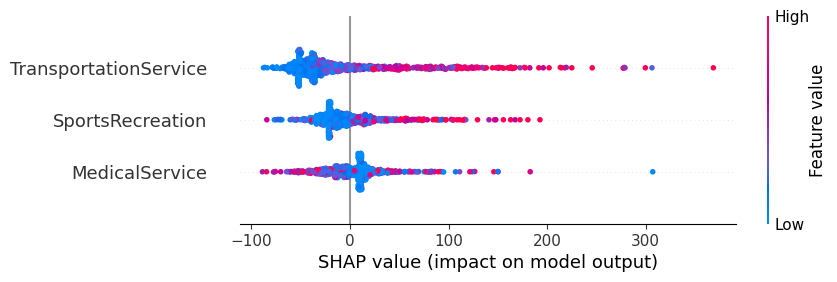

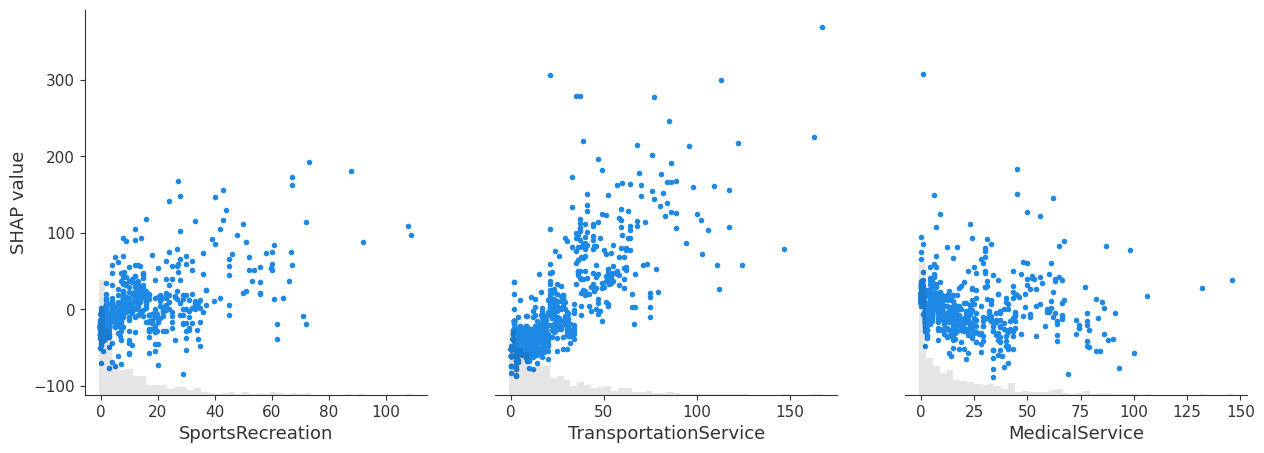

In [65]:
import shap

explainer = shap.TreeExplainer(xgb_model, feature_names=X.columns)
shap_values = explainer(X_train)

shap.plots.beeswarm(shap_values)
shap.plots.scatter(shap_values)

We see that higher densities of sports and transport POIs are associated with more bike trips, while high densities of medical POIs tend to be associated with fewer bike trips. Intuitively, this makes sense, since a trip to the doctor might be less likely to be biked than a trip to a sports facility or a trip to a transit station.

Developing accurate models of the relationship between POIs and trip densities allows us to understand bike-sharing usage patterns. This patterns can be used to make sure that there are enough bikes at stands to meet demand. It can also inform where to set up new bike stands. Analyzing the POIs and geographic regions with low trip densities may reveal lack of biking infrastructure such as bike lanes, bike stands, etc. or other issues that need to be addressed.

<a name="policy-advice"></a>

## Deriving policy advice: Using the model to determine the optimal locations for future bike stands

**Before you start:** keep in mind this exercise treats model output as a planning suggestion, not a decision. In a real deployment, results like these would need field validation and input from affected communities and local planners before any bike stand is actually built.

**A key caveat:** this model only learned a *correlation* between POIs and trips at *existing* bike stands — it was never shown what happens when a new stand is added somewhere. High POI density near a current stand does not mean building a new stand nearby would *cause* similar demand; unobserved factors (e.g. why a stand was placed there in the first place) could explain the pattern instead. Treat the exercise below as generating hypotheses to test, not causal predictions.

### Exercise 4

<a name="task-policy-advice"></a>

⭐ **YOUR TURN!**
Instead of looking only at areas where bike stands already exist, let's look at other areas and use our fitted model to estimate where a new bike stand is likely to attract the most cyclists.
Feel free to use the model you are most comfortable with for this task.

In [67]:
# Determine locations where no bike stands yet exist / no trips end
new_locations = poi_counts[~poi_counts.index.isin(trips.index)]

# Predict number of trips that might end there if new bike stands were installed, given the local POI density
new_locations['trip_count_pred'] = xgb_model.predict(new_locations[['SportsRecreation', 'TransportationService', 'MedicalService']])

# Visualize potential of locations
new_locations.h3.h3_to_geo_boundary().explore('trip_count_pred')

/tmp/ipykernel_903/3579243822.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_locations['trip_count_pred'] = xgb_model.predict(new_locations[['SportsRecreation', 'TransportationService', 'MedicalService']])


#### Solution

In [ ]:
# SOLUTION

# Determine locations where no bike stands yet exist / no trips end
new_locations = poi_counts[~poi_counts.index.isin(trips.index)]

# Predict number of trips that might end there if new bike stands were installed, given the local POI density
new_locations['trip_count_pred'] = xgb_model.predict(new_locations[['SportsRecreation', 'TransportationService', 'MedicalService']])

# Visualize potential of locations
new_locations.h3.h3_to_geo_boundary().explore('trip_count_pred')

Great! There are a number of locations for new bike racks where we expect a large number of trips to end.

Some of them are close to existing bike racks. Let's take a look at which ones are not within walking distance of existing bike racks and highlight them in our policy recommendations.

In [68]:
# Identify locations which are close to existing bike racks
locations_close_to_existing_stands = trips.h3.hex_ring()['h3_hex_ring'].explode().values

# Exclude these locations so that only locations far from existing bike racks remain
new_locations_away_from_existing_stands = new_locations[~new_locations.index.isin(locations_close_to_existing_stands)]

# Visualize potential of these locations
new_locations_away_from_existing_stands.h3.h3_to_geo_boundary().explore('trip_count_pred')

<a name="next-steps"></a>

## Next Steps
* How does using all the trip data instead of a subset affect the performance of our models?
* How can our models be used to determine where bikers are headed at different times of the day and different times of the week?
* The data folder contains a map of the bike paths in Shenzhen. How does the existence and/or non-existence of bike paths affect trip densities?

### Pathway to deployment
Turning a notebook like this into something a city could actually use would require several more steps:

* Community and stakeholder input from the start. The planners, bike-share operators, and residents named earlier (see Climate Impact) should help define what "success" looks like and flag areas at risk of being underserved, before a model shapes real investment decisions
* Local validation against known ground truth (e.g. a pilot deployment before city-wide rollout)
* Access to the full trip and POI data (or a live data feed), not a subsample
* Additional features known to matter locally (e.g. bike lane coverage, land use, income)
* A retraining/monitoring plan, since mobility patterns shift over time (e.g. post-pandemic changes)
* Sign-off from transport planners before any model output informs a real infrastructure decision


<a name="references"></a>
# References

* Willing, Christoph, Konstantin Klemmer, Tobias Brandt, and Dirk Neumann. “Moving in Time and Space – Location Intelligence for Carsharing Decision Support.” Decision Support Systems 99 (July 2017): 75–85. https://doi.org/10.1016/j.dss.2017.05.005.

* Wagner, Felix, Nikola Milojevic-Dupont, Lukas Franken, Aicha Zekar, Ben Thies, Nicolas Koch, and Felix Creutzig. “Using Explainable Machine Learning to Understand How Urban Form Shapes Sustainable Mobility.” Transportation Research Part D: Transport and Environment 111 (October 2022): 103442. https://doi.org/10.1016/j.trd.2022.103442.

* Geng X, Li Y, Wang L, Zhang L, Yang Q, Ye J, Liu Y (2019) Spatiotemporal multigraph convolution network for ride-hailing demand forecasting. In: Proceedings
of the AAAI conference on artificial intelligence, vol 33, pp 3656–3663
